In [ ]:
# question 1a
import math
known = [2, 2, 3, 3, 5, 5]
current_sum = 0 
for i in known:
    current_sum += 2 ** (-i)
# 2^-m <= 1-current_sum
m=-math.log2(1-current_sum)
# sign flips from negative so ceiling
print(f"m = {math.ceil(m)}") # M


# question 1b
known = [2, 2, 3, 3, 3, 5, 5]
probabilities = []
for i in range(len(known)-1):
    probabilities.append(2 ** (-known[i]))
probs = sum(probabilities)
probabilities.append(1-probs)
print(probabilities)
print(probs+probabilities[-1]) # proof its 1

avg_length = 0
for i in range(len(probabilities)):
    avg_length += known[i] * probabilities[i]

values = [i * math.log2(i) for i in probabilities]
print(f"Entropy = {-sum(values)}") # ENTROPY
print(f"Avg Code Length = {avg_length}")


m = 3
[0.25, 0.25, 0.125, 0.125, 0.125, 0.03125, 0.09375]
1.0
Entropy = 2.6014097655573916
Avg Code Length = 2.75


In [3]:
# question 2
import math

dms = [0.25, 0.22, 0.18, 0.15, 0.06, 0.05, 0.05, 0.04]
lengths = [2, 2, 3, 3, 4, 4, 4, 4]

L = sum(dms[i] * lengths[i] for i in range(len(dms)))
print(L)

entropy = - sum(i * math.log2(i) for i in dms)
print(entropy)


2.73
2.6979065370979387


/tmp/ipykernel_2718/1599492669.py:11: RuntimeWarning: divide by zero encountered in log2
  h_bsc = -p_bsc * np.log2(p_bsc) - (1 - p_bsc) * np.log2(1 - p_bsc) # had to use np log2 here for comptability
/tmp/ipykernel_2718/1599492669.py:11: RuntimeWarning: invalid value encountered in multiply
  h_bsc = -p_bsc * np.log2(p_bsc) - (1 - p_bsc) * np.log2(1 - p_bsc) # had to use np log2 here for comptability


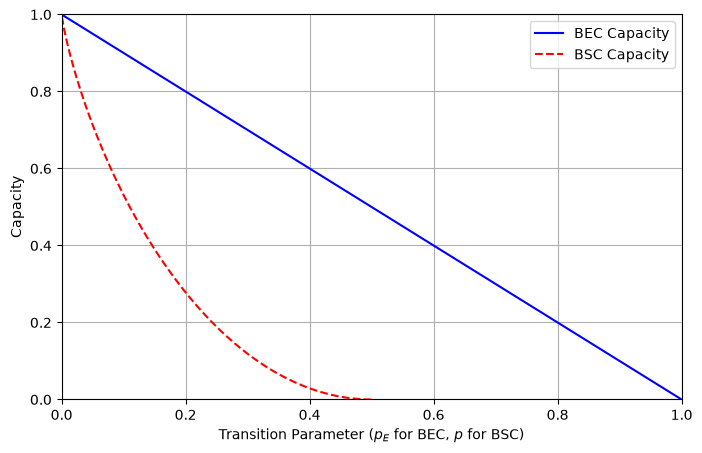

In [8]:
# q3

import numpy as np
import matplotlib.pyplot as plt

pe = np.linspace(0, 1, 1000)
p_bsc = np.linspace(0, 0.5, 1000)

c_bec = 1 - pe

h_bsc = -p_bsc * np.log2(p_bsc) - (1 - p_bsc) * np.log2(1 - p_bsc) # had to use np log2 here for comptability
c_bsc = 1 - h_bsc

plt.figure(figsize=(8, 5))
plt.plot(pe, c_bec, 'b-', label=r'BEC Capacity')
plt.plot(p_bsc, c_bsc, 'r--', label=r'BSC Capacity')
plt.xlabel('Transition Parameter ($p_E$ for BEC, $p$ for BSC)')
plt.ylabel('Capacity')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True)
plt.legend()
plt.show()

lambda = 0.2, R = 5.114409345247941, D = 0.7000000000000001
lambda = 0.4, R = 3.6144093452479407, D = 1.3000000000000003
lambda = 0.6, R = 2.736965594166206, D = 1.9000000000000004
lambda = 0.8, R = 2.11440934524794, D = 2.5000000000000004
lambda = 1.0, R = 1.792481250360578, D = 2.9
lambda = 1.2, R = 1.5294468445267844, D = 3.3000000000000003
lambda = 1.4, R = 1.307054423190336, D = 3.7000000000000006
lambda = 1.6, R = 1.1144093452479404, D = 4.1
lambda = 1.8, R = 0.9444843438056281, D = 4.5
lambda = 2.0, R = 0.792481250360578, D = 4.8999999999999995
lambda = 2.2, R = 0.6549777266106431, D = 5.3
lambda = 2.4, R = 0.529446844526784, D = 5.7
lambda = 2.6, R = 0.4139696271068479, D = 6.1000000000000005
lambda = 2.8, R = 0.3070544231903362, D = 6.5
lambda = 3.0, R = 0.20751874963942174, D = 6.8999999999999995

Chosen lambda_1 = 0.8 -> R_1 = 2.1144 (> 2)
Chosen lambda_2 = 1.0 -> R_2 = 1.7925 (< 2)

Proposed lambda = 0.8660660660660661
R for proposed lambda R = 1.99993226307838
D for propos

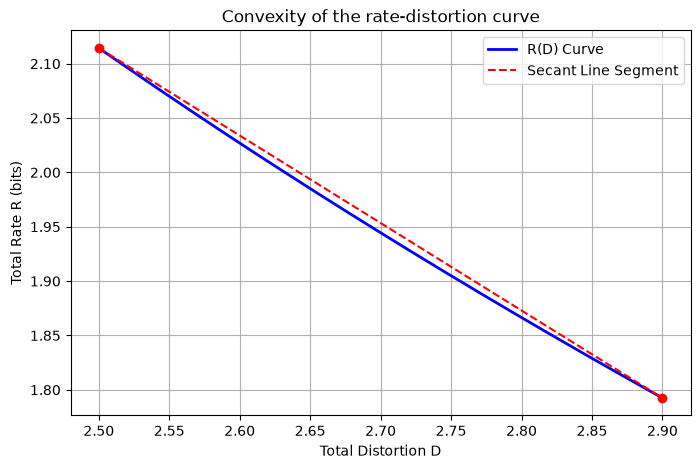

Increasing lambda increases D but decreases R

Proposed lambda: 0.8660660660660661
Total Rate D   : 2.6321321321321323
Total Rate R   : 1.99993226307838 bits

Component Variance Distortion Rate all for proposed lambda
140.86606606606606611.1037255063589009
230.86606606606606610.8962067567194791
30.80.80.0
40.10.10.0

Components not encoded (R_i = 0): [3, 4]


In [4]:
# question 5

variances = [4, 3, 0.8, 0.1]
import numpy as np
import matplotlib.pyplot as plt

def compute_d_r_components(_lambda, variances): # written this way for part e
    variances = np.asarray(variances, dtype=float)
    D_i = np.minimum(_lambda, variances)
    R_i = np.maximum(0.0, 0.5 * np.log2(variances / _lambda))
    return D_i, R_i

def compute_d_r(_lambda, variances):
    components_d, components_r = compute_d_r_components(_lambda, variances)
    return np.sum(components_d), np.sum(components_r)

# part b (trial error)



multiples_of_0_2 = np.arange(0.2, 3.2, 0.2) # step size 0.2 means integer multiples of 0.2
for lam in multiples_of_0_2:
    D_val, R_val = compute_d_r(lam, variances)
    print(f"lambda = {lam:.1f}, R = {R_val}, D = {D_val}") # i added the .1f for weird fp precision

# we see that lambda = 0.8 produces R=2.1 and lambda 1.0 produces 1.79, closest values
lambda_1 = 0.8
lambda_2 = 1.0
D_1, R_1 = compute_d_r(lambda_1, variances)
D_2, R_2 = compute_d_r(lambda_2, variances)

print(f"\nChosen lambda_1 = {lambda_1:.1f} -> R_1 = {R_1:.4f} (> 2)")
print(f"Chosen lambda_2 = {lambda_2:.1f} -> R_2 = {R_2:.4f} (< 2)")

dense_lambdas = np.linspace(lambda_1, lambda_2, 1000)
proposed_lambda = None
for lam in dense_lambdas:
    D_val, R_val = compute_d_r(lam, variances)
    if 1.99 < R_val <= 2.0:
        proposed_lambda = lam
        proposed_D = D_val
        proposed_R = R_val
        break

print(f"\nProposed lambda = {proposed_lambda}")
print(f"R for proposed lambda R = {proposed_R}")
print(f"D for proposed lambda = {proposed_D}")



# part C

lam_curve = np.linspace(lambda_1, lambda_2, 300)
D_curve = []
R_curve = []

for lam in lam_curve:
    d, r = compute_d_r(lam, variances)
    D_curve.append(d)
    R_curve.append(r)

plt.figure(figsize=(8, 5))
plt.plot(D_curve, R_curve, 'b-', linewidth=2, label='R(D) Curve')
plt.plot([D_1, D_2], [R_1, R_2], 'r--', linewidth=1.5, label='Secant Line Segment')
plt.scatter([D_1, D_2], [R_1, R_2], color='red', zorder=5)

plt.xlabel('Total Distortion D')
plt.ylabel('Total Rate R (bits)')
plt.title('Convexity of the rate-distortion curve')
plt.legend()
plt.grid(True)
plt.show()


# part D

print("Increasing lambda increases D but decreases R")

# part E

D_components, R_components = compute_d_r_components(proposed_lambda, variances)
total_D, total_R = compute_d_r(proposed_lambda, variances)

print(f"\nProposed lambda: {proposed_lambda}")
print(f"Total Rate D   : {total_D}")
print(f"Total Rate R   : {total_R} bits\n")

print(f"{'Component'} {'Variance'} {'Distortion'} {'Rate'} all for proposed lambda")
for i in range(len(variances)):
    print(f"{i+1}{variances[i]}{D_components[i]}{R_components[i]}")

unencoded = [i + 1 for i, r in enumerate(R_components) if r == 0.0] # awesome list comprehension!
print(f"\nComponents not encoded (R_i = 0): {unencoded}")
